#**Challenge Alura Store**

### Importación de datos



In [33]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [92]:
t_tienda1 = tienda['Precio'].sum()
t_tienda2 = tienda2['Precio'].sum()
t_tienda3 = tienda3['Precio'].sum()
t_tienda4 = tienda4['Precio'].sum()

print(f"El ingreso total de la tienda 1 es de: {t_tienda1:,}$")
print(f"El ingreso total de la tienda 2 es de: {t_tienda2:,}$")
print(f"El ingreso total de la tienda 3 es de: {t_tienda3:,}$")
print(f"El ingreso total de la tienda 4 es de: {t_tienda4:,}$")

El ingreso total de la tienda 1 es de: 1,150,880,400.0$
El ingreso total de la tienda 2 es de: 1,116,343,500.0$
El ingreso total de la tienda 3 es de: 1,098,019,600.0$
El ingreso total de la tienda 4 es de: 1,038,375,700.0$


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

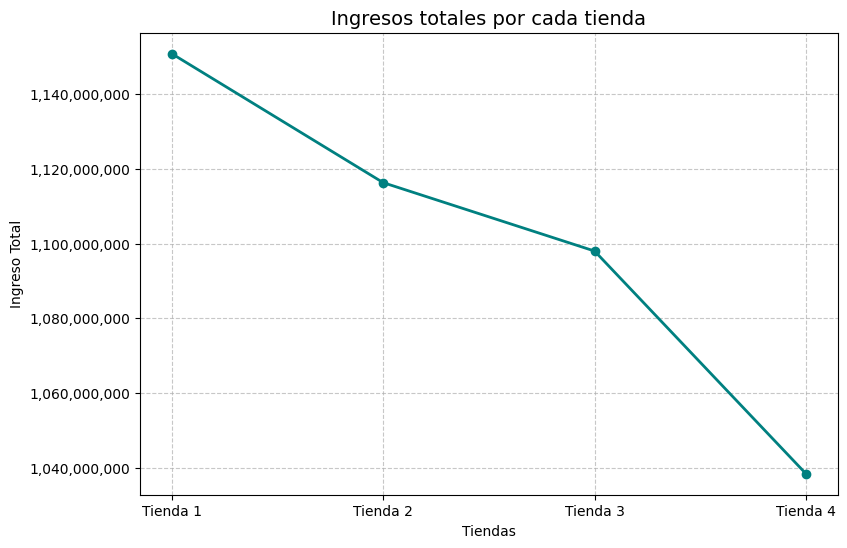

In [96]:
df_ingresos = pd.DataFrame({
    'Tiendas': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso Total': [t_tienda1, t_tienda2, t_tienda3, t_tienda4]})

plt.figure(figsize=(9, 6))
plt.plot(df_ingresos['Tiendas'], df_ingresos['Ingreso Total'], marker='o', linestyle='-', color='teal', linewidth=2)
formatter = ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Ingresos totales por cada tienda', fontsize=14)
plt.xlabel('Tiendas')
plt.ylabel('Ingreso Total')
plt.grid(linestyle='--', alpha=0.7)

plt.show()

# 2. Ventas por categoría

In [97]:
#Con .sort_values(ascending=False) podemos ver las categorias + populares de las 4 tiendas
vcat_t1 = (tienda.groupby('Categoría del Producto')['Producto'] .count() .sort_values(ascending=False))
vcat_t2 = (tienda2.groupby('Categoría del Producto')['Producto'].count().sort_values(ascending=False))
vcat_t3 = (tienda3.groupby('Categoría del Producto')['Producto'].count().sort_values(ascending=False))
vcat_t4 = (tienda4.groupby('Categoría del Producto')['Producto'].count().sort_values(ascending=False))

print("Las ventas por categoria de tienda 1 son...")
print(vcat_t1, "\n")

print("Las ventas por categoria de tienda 2 son...")
print(vcat_t2, "\n")

print("Las ventas por categoria de tienda 3 son...")
print(vcat_t3, "\n")

print("Las ventas por categoria de tienda 4 son...")
print(vcat_t4, "\n")

Las ventas por categoria de tienda 1 son...
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: Producto, dtype: int64 

Las ventas por categoria de tienda 2 son...
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: Producto, dtype: int64 

Las ventas por categoria de tienda 3 son...
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Artículos para el hogar    177
Instrumentos musicales  

####Grafica de ventas por categoria

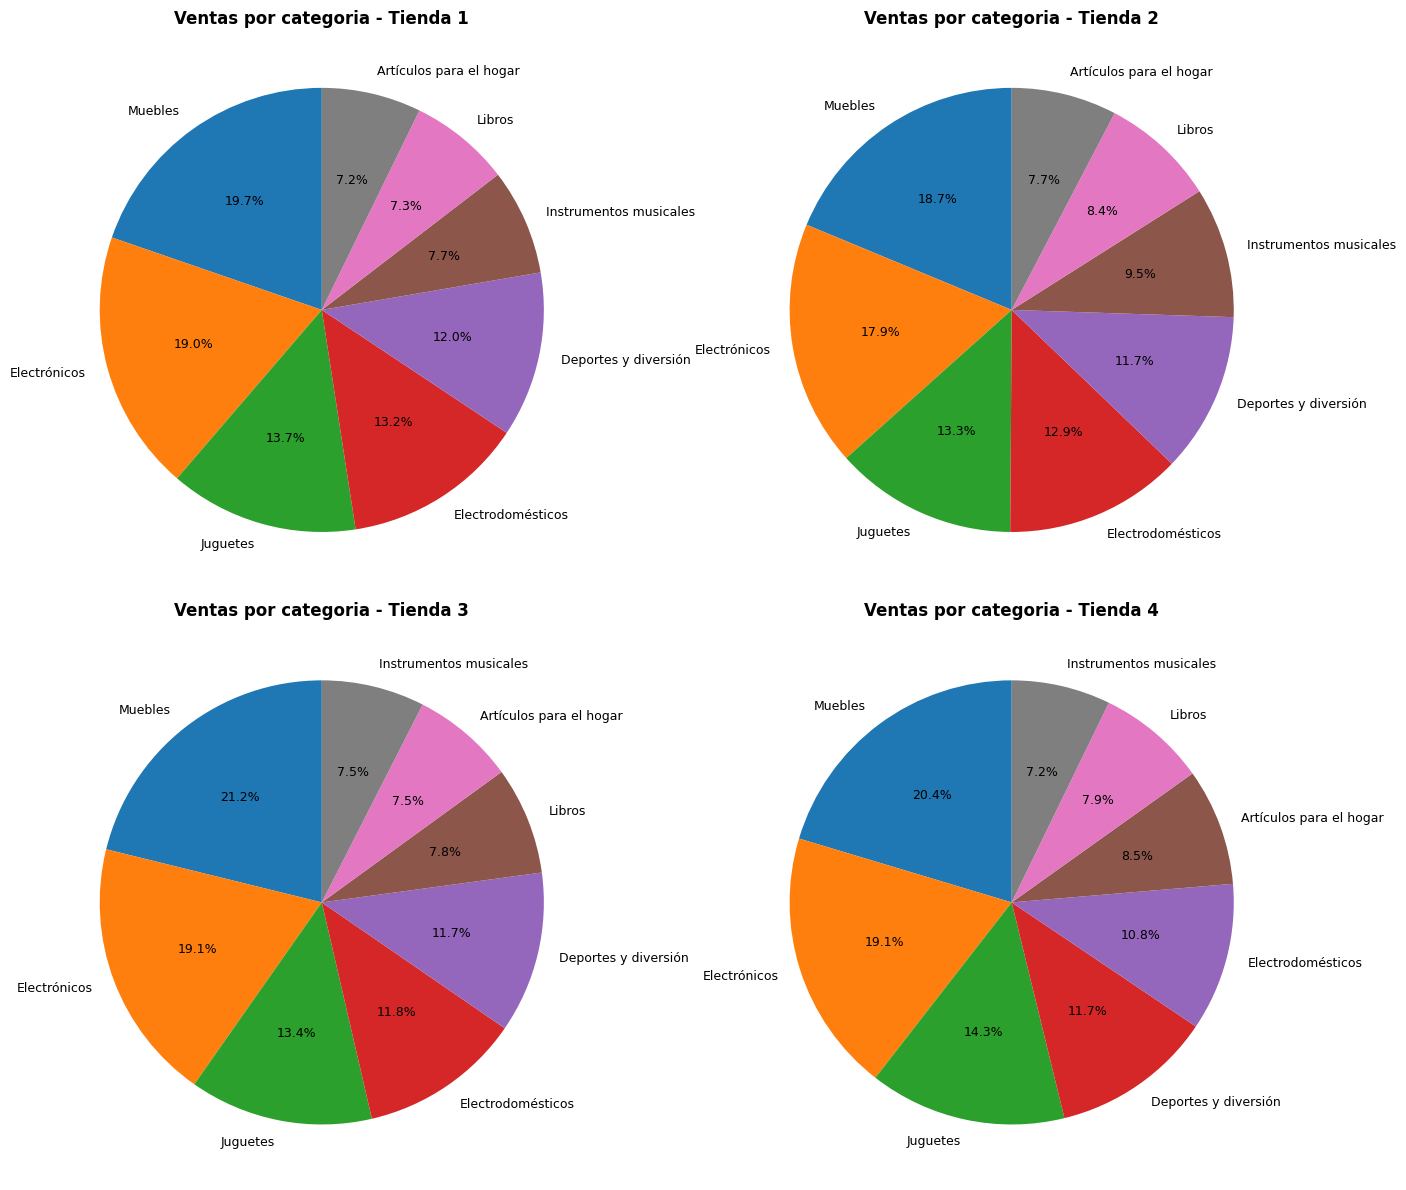

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

tiendas = [('Tienda 1', vcat_t1),('Tienda 2', vcat_t2),('Tienda 3', vcat_t3),('Tienda 4', vcat_t4)]

for ax, (nombre, datos) in zip(axes, tiendas):
    datos.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90, fontsize=9)
    ax.set_title(f'Ventas por categoria - {nombre}', fontsize=12, fontweight='bold')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


####Valoracion media de cada tienda

In [38]:
vmed_t1 = (tienda.groupby('Categoría del Producto')['Calificación'].mean().sort_values(ascending=False))
vmed_t2 = (tienda2.groupby('Categoría del Producto')['Calificación'].mean().sort_values(ascending=False))
vmed_t3 = (tienda3.groupby('Categoría del Producto')['Calificación'].mean().sort_values(ascending=False))
vmed_t4 = (tienda4.groupby('Categoría del Producto')['Calificación'].mean().sort_values(ascending=False))

In [39]:
vmedia_t1 = tienda['Calificación'].mean()
vmedia_t2 = tienda2['Calificación'].mean()
vmedia_t3 = tienda3['Calificación'].mean()
vmedia_t4 = tienda4['Calificación'].mean()

print("La valoracion media de tienda 1 es de:", round(vmedia_t1, 3))
print("La valoracion media de tienda 2 es de:", round(vmedia_t2, 3))
print("La valoracion media de tienda 3 es de:", round(vmedia_t3, 3))
print("La valoracion media de tienda 4 es de:", round(vmedia_t4, 3))

La valoracion media de tienda 1 es de: 3.977
La valoracion media de tienda 2 es de: 4.037
La valoracion media de tienda 3 es de: 4.048
La valoracion media de tienda 4 es de: 3.996


####Grafica de valoracion media

In [ ]:
import matplotlib.pyplot as plt

In [99]:
tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
valoraciones = [vmedia_t1, vmedia_t2, vmedia_t3, vmedia_t4]

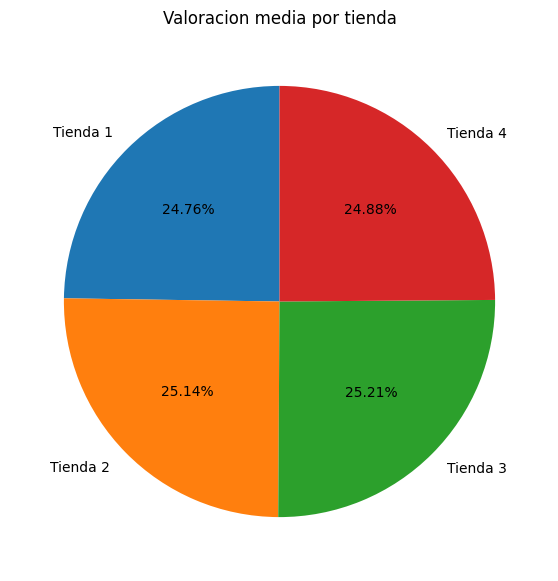

In [100]:
plt.figure(figsize=(7, 7))
plt.pie(valoraciones,labels=tiendas,autopct='%1.2f%%',startangle=90)
plt.title('Valoracion media por tienda')
plt.show()

####Satisfaccion del cliente y en que categoria caen estos productos

In [102]:
print("La valoración media por tienda 1 por:", round(vmed_t1, 2), "\n")

print("La valoracion media por tienda 2 por:", round(vmed_t2, 2), "\n")

print("La valoracion media por tienda 3 por:", round(vmed_t3, 2), "\n")

print("La valoracion media por tienda 4 por:", round(vmed_t4, 2))

La valoración media por tienda 1 por: Categoría del Producto
Juguetes                   4.08
Instrumentos musicales     4.05
Electrodomésticos          4.03
Electrónicos               4.00
Libros                     3.98
Muebles                    3.95
Deportes y diversión       3.90
Artículos para el hogar    3.75
Name: Calificación, dtype: float64 

La valoracion media por tienda 2 por: Categoría del Producto
Muebles                    4.09
Electrodomésticos          4.07
Artículos para el hogar    4.07
Deportes y diversión       4.07
Instrumentos musicales     4.04
Juguetes                   4.03
Electrónicos               3.97
Libros                     3.95
Name: Calificación, dtype: float64 

La valoracion media por tienda 3 por: Categoría del Producto
Juguetes                   4.20
Muebles                    4.10
Artículos para el hogar    4.07
Libros                     4.05
Electrodomésticos          4.01
Instrumentos musicales     4.01
Electrónicos               3.99
Deporte

# 4. Productos más y menos vendidos

###Productos MAS Vendidos

In [64]:
ventasp_t1 = tienda.groupby('Producto').size().sort_values(ascending=False)
ventasp_t2 = tienda2.groupby('Producto').size().sort_values(ascending=False)
ventasp_t3 = tienda3.groupby('Producto').size().sort_values(ascending=False)
ventasp_t4 = tienda4.groupby('Producto').size().sort_values(ascending=False)

ventas_may_t1 = ventasp_t1.head(6)
ventas_men_t1 = ventasp_t1.tail(6)

ventas_may_t2 = ventasp_t2.head(6)
ventas_men_t2 = ventasp_t2.tail(6)

ventas_may_t3 = ventasp_t3.head(6)
ventas_men_t3 = ventasp_t3.tail(6)

ventas_may_t4 = ventasp_t4.head(6)
ventas_men_t4 = ventasp_t4.tail(6)

In [66]:
print("Los productos MAS vendidos en tienda 1 son:")
print(ventas_may_t1, "\n")

print("Los productos MAS vendidos en tienda 2 son:")
print(ventas_may_t2, "\n",)

print("Los productos MAS vendidos en tienda 3 son:")
print(ventas_may_t3, "\n")

print("Los productos MAS vendidos en tienda 4 son:")
print(ventas_may_t4, "\n")

Los productos MAS vendidos en tienda 1 son:
Producto
Armario                    60
TV LED UHD 4K              60
Microondas                 60
Secadora de ropa           58
Mesa de noche              56
Bloques de construcción    56
dtype: int64 

Los productos MAS vendidos en tienda 2 son:
Producto
Iniciando en programación    65
Microondas                   62
Batería                      61
Pandereta                    58
Guitarra acústica            58
Secadora de ropa             57
dtype: int64 

Los productos MAS vendidos en tienda 3 son:
Producto
Kit de bancas      57
Mesa de comedor    56
Cama king          56
Set de ollas       55
Mesa de noche      55
Smart TV           54
dtype: int64 

Los productos MAS vendidos en tienda 4 son:
Producto
Cama box                     62
Cubertería                   59
Cama king                    56
Dashboards con Power BI      56
Carrito de control remoto    55
Mesa de noche                55
dtype: int64 



####Grafico de los + vendidos

In [65]:
import matplotlib.pyplot as plt

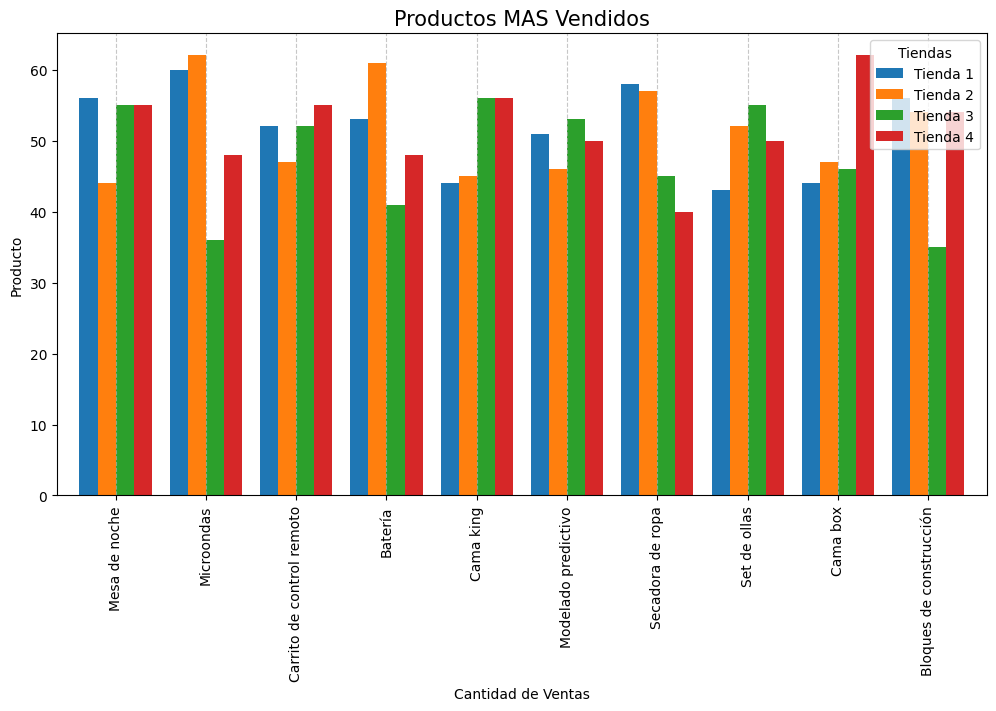

In [47]:
df_comparativo = pd.DataFrame({'Tienda 1': ventasp_t1,'Tienda 2': ventasp_t2,'Tienda 3': ventasp_t3,'Tienda 4': ventasp_t4}).fillna(0)
df_comparativo['Total Ventas'] = df_comparativo.sum(axis=1)

top_vendidos = df_comparativo.sort_values(by='Total Ventas',ascending=False).head(10)
top_vendidos.drop(columns='Total Ventas').plot(kind='bar',figsize=(12, 6),width=0.8)

plt.title('Productos MAS Vendidos', fontsize=15)
plt.xlabel('Cantidad de Ventas')
plt.ylabel('Producto')
plt.legend(title='Tiendas')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

###Productos MENOS Vendidos

In [45]:
print("Los productos MENOS vendidos en tienda 1 son:")
print(ventas_men_t1, "\n", "----------------")

print("Los productos MENOS vendidos en tienda 2 son:")
print(ventas_men_t2, "\n", "----------------")

print("Los productos MENOS vendidos en tienda 3 son:")
print(ventas_men_t3, "\n", "----------------")

print("Los productos MENOS vendidos en tienda 4 son:")
print(ventas_men_t4, "\n", "----------------")

Los productos MENOS vendidos en tienda 1 son:
Producto
Ciencia de datos con Python    39
Mochila                        39
Pandereta                      36
Olla de presión                35
Celular ABXY                   33
Auriculares con micrófono      33
dtype: int64 
 ----------------
Los productos MENOS vendidos en tienda 2 son:
Producto
Asistente virtual    38
Auriculares          37
Sillón               35
Impresora            34
Mesa de comedor      34
Juego de mesa        32
dtype: int64 
 ----------------
Los productos MENOS vendidos en tienda 3 son:
Producto
Vaso térmico               38
Guitarra eléctrica         38
Mochila                    36
Microondas                 36
Set de vasos               36
Bloques de construcción    35
dtype: int64 
 ----------------
Los productos MENOS vendidos en tienda 4 son:
Producto
Lavadora de ropa               38
Ciencia de datos con Python    38
Refrigerador                   38
Guitarra acústica              37
Armario             

####Grafico de los - vendidos

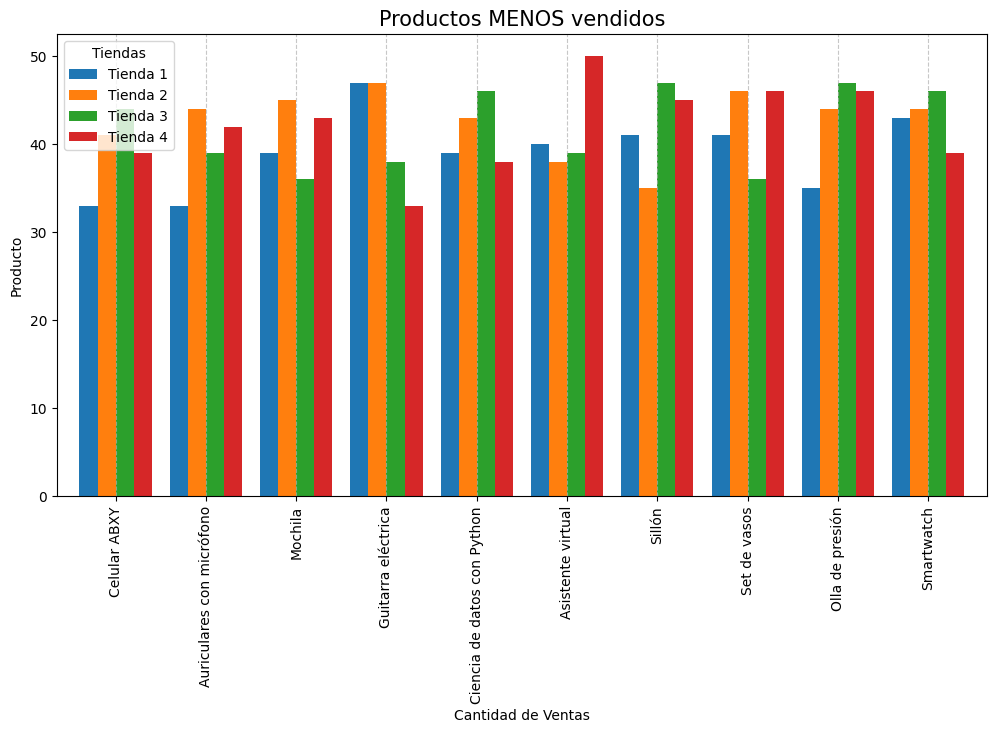

In [48]:
menos_vendidos = df_comparativo.sort_values(by='Total Ventas',ascending=True).head(10)
menos_vendidos.drop(columns='Total Ventas').plot(kind='bar',figsize=(12, 6),width=0.8)

plt.title('Productos MENOS vendidos', fontsize=15)
plt.xlabel('Cantidad de Ventas')
plt.ylabel('Producto')
plt.legend(title='Tiendas')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 5. Envío promedio por tienda

In [49]:
enviop_t1 = tienda['Costo de envío'].mean()
enviop_t2 = tienda2['Costo de envío'].mean()
enviop_t3 = tienda3['Costo de envío'].mean()
enviop_t4 = tienda4['Costo de envío'].mean()

print("El valor del envio promedio por tienda es: \n")
print(f"De tienda 1 es de: {enviop_t1:.2f} $")
print(f"De tienda 2 es de: {enviop_t2:.2f} $")
print(f"De tienda 3 es de: {enviop_t3:.2f} $")
print(f"De tienda 4 es de: {enviop_t4:.2f} $")

El valor del envio promedio por tienda es: 

De tienda 1 es de: 26018.61 $
De tienda 2 es de: 25216.24 $
De tienda 3 es de: 24805.68 $
De tienda 4 es de: 23459.46 $


####Grafico sobre el costo de envio

In [50]:
import matplotlib.pyplot as plt

In [51]:
enviop = pd.DataFrame({'Tiendas': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
                       'Costo envio promedio': [enviop_t1, enviop_t2, enviop_t3, enviop_t4]})

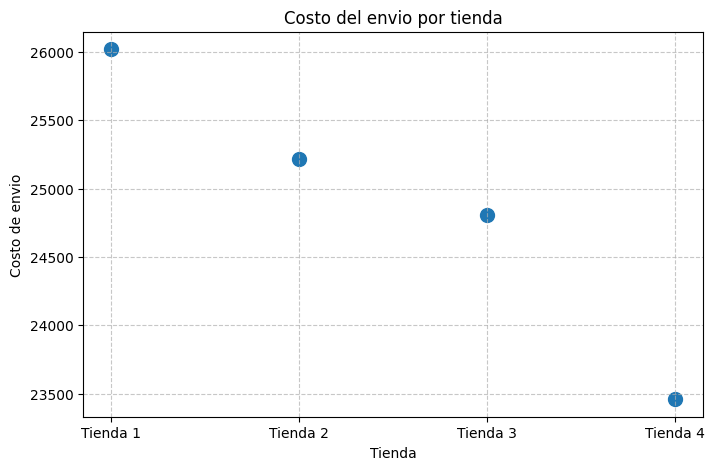

In [52]:
plt.figure(figsize=(8, 5))
plt.scatter(enviop['Tiendas'], enviop['Costo envio promedio'], s=100)
plt.title('Costo del envio por tienda')
plt.xlabel('Tienda')
plt.ylabel('Costo de envio')
plt.grid(linestyle='--', alpha=0.7)

plt.show()

#Informe Final
####Con los ingresos totales podemos notar que la tienda 4 es la que presenta el valor mas bajo en comparación con las demas, lo cual deja en evidencia su bajo rendimiento a nivel general. Por tanto, se recomienda que el Sr. Juan venda la Tienda 4 pues es la opcion menos rentable, ya para mayor informacion por favor leer el README
